In [24]:
#SET UP CELL
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import gzip
from google.colab import drive

os.environ["SCIPY_ARRAY_API"] = "1"

from inmoose.pycombat import pycombat_norm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from boruta import BorutaPy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    classification_report,
    confusion_matrix
)

drive.mount('/content/drive')

# Establish the pathing structure to your project vault
PROJECT_PATH = "/content/drive/MyDrive/PD ISEF project"
RAW_DIR = os.path.join(PROJECT_PATH, "data/raw/")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
os.environ["SCIPY_ARRAY_API"] = "1"


In [3]:
#LOAD 2020
file_2020 = os.path.join(RAW_DIR, 'GSE269775_raw_counts.xlsx')
df_2020_raw = pd.read_excel(file_2020, header=1)
print(df_2020_raw.shape)#old

#doesnt affect ai's prediction
unwanted = ['Chr', 'Start', 'End', 'Strand', 'Length']

df_2020_clean = df_2020_raw.drop(columns = unwanted)

df_2020_clean.set_index('Geneid', inplace=True)

print(df_2020_clean.shape)#new

(2794, 106)
(2794, 100)


In [4]:
#LOAD 2022 and 2023
file_2022 = os.path.join(RAW_DIR, 'GSE269777_raw_counts.xlsx')
file_2023 = os.path.join(RAW_DIR, 'GSE269779_raw_counts.xlsx')

df_2022_clean = pd.read_excel(file_2022)
print(df_2022_clean.shape)
df_2023_clean = pd.read_excel(file_2023)
print(df_2023_clean.shape)

df_2022_clean.set_index('Gene', inplace=True)
df_2023_clean.set_index('Gene', inplace=True)

print(df_2022_clean.shape)
print(df_2023_clean.shape)

(2792, 121)
(2792, 101)
(2792, 120)
(2792, 100)


In [5]:
df_merged = pd.concat([df_2020_clean, df_2022_clean, df_2023_clean], join='inner',axis=1)

In [6]:
column_totals = df_merged.sum()
df_cpm = (df_merged / column_totals) * 1e6
#we're using cpm to normalize variations

In [7]:
df_filtered = df_cpm[(df_cpm >= 1).sum(axis=1) >= 32]
print(df_filtered.shape)

(1065, 320)


In [8]:
metadata_file = os.path.join(RAW_DIR, 'SraRunTable.csv')
df_meta = pd.read_csv(metadata_file)
raw_labels = df_meta['disease_state'].values
y_full = np.where(raw_labels == 'PD', 1, 0)
batches = np.array(['2020']*143 + ['2022']*105 + ['2023']*71)
y_full_labels = y_full[:319]
batches_array = np.array(batches[:319])

print("Labels aligned. Class distribution:", np.bincount(y_full_labels))

Labels aligned. Class distribution: [223  96]


In [9]:
df_log2 = np.log2(df_filtered + 1)
X_raw_log = df_log2.T

y_full_labels = y_full[:319]
batches_array = np.array(batches[:319])
X_raw_log = X_raw_log.iloc[:319]

In [10]:
X_train_raw, X_test_raw, y_train, y_test, batch_train, batch_test = train_test_split(
    X_raw_log,
    y_full_labels,
    batches_array,
    test_size=0.2,
    stratify=y_full_labels,
    random_state=42
)

In [11]:
X_train_corrected_arr = pycombat_norm(counts=X_train_raw.T, batch=list(batch_train))
X_train = pd.DataFrame(X_train_corrected_arr, index=X_train_raw.columns, columns=X_train_raw.index).T

X_test_corrected_arr = pycombat_norm(counts=X_test_raw.T.values, batch=list(batch_test))
X_test = pd.DataFrame(X_test_corrected_arr, index=X_test_raw.columns, columns=X_test_raw.index).T

  np.amax(np.absolute(d_new - d_old) / d_old),



In [12]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [13]:
print(df_meta['Sample Name'].head(10).tolist())
print(df_meta[['Run', 'Sample Name', 'Library Name']].head(5))

['GSM8326866', 'GSM8326865', 'GSM8326864', 'GSM8326863', 'GSM8326862', 'GSM8326861', 'GSM8326860', 'GSM8326859', 'GSM8326858', 'GSM8326857']
           Run Sample Name Library Name
0  SRR29397945  GSM8326866   GSM8326866
1  SRR29397946  GSM8326865   GSM8326865
2  SRR29397947  GSM8326864   GSM8326864
3  SRR29397948  GSM8326863   GSM8326863
4  SRR29397949  GSM8326862   GSM8326862


In [14]:
df_meta[['Run', 'Sample Name', 'disease_state']].head(15)

,Run,Sample Name,disease_state
0,SRR29397945,GSM8326866,Control
1,SRR29397946,GSM8326865,Control
2,SRR29397947,GSM8326864,Control
3,SRR29397948,GSM8326863,Control
4,SRR29397949,GSM8326862,Control
5,SRR29397950,GSM8326861,Control
6,SRR29397951,GSM8326860,Control
7,SRR29397952,GSM8326859,Control
8,SRR29397953,GSM8326858,Control
9,SRR29397954,GSM8326857,Control


In [15]:
boruta_engine = RandomForestClassifier(
    n_estimators="auto", class_weight="balanced", max_depth=5, random_state=42
)

boruta_selector = BorutaPy(
    estimator=boruta_engine, n_estimators="auto", verbose=2, max_iter=100, random_state=42
)

X_train_np = (
    X_train_scaled.values
    if hasattr(X_train_scaled, "values")
    else np.array(X_train_scaled)
)
y_train_np = y_train.values if hasattr(y_train, "values") else np.array(y_train)

boruta_selector.fit(X_train_np, y_train_np)

Iteration: 	1 / 100
Confirmed: 	0
Tentative: 	1065
Rejected: 	0
Iteration: 	2 / 100
Confirmed: 	0
Tentative: 	1065
Rejected: 	0
Iteration: 	3 / 100
Confirmed: 	0
Tentative: 	1065
Rejected: 	0
Iteration: 	4 / 100
Confirmed: 	0
Tentative: 	1065
Rejected: 	0
Iteration: 	5 / 100
Confirmed: 	0
Tentative: 	1065
Rejected: 	0
Iteration: 	6 / 100
Confirmed: 	0
Tentative: 	1065
Rejected: 	0
Iteration: 	7 / 100
Confirmed: 	0
Tentative: 	1065
Rejected: 	0
Iteration: 	8 / 100
Confirmed: 	0
Tentative: 	140
Rejected: 	925
Iteration: 	9 / 100
Confirmed: 	21
Tentative: 	119
Rejected: 	925
Iteration: 	10 / 100
Confirmed: 	21
Tentative: 	119
Rejected: 	925
Iteration: 	11 / 100
Confirmed: 	21
Tentative: 	119
Rejected: 	925
Iteration: 	12 / 100
Confirmed: 	34
Tentative: 	88
Rejected: 	943
Iteration: 	13 / 100
Confirmed: 	34
Tentative: 	88
Rejected: 	943
Iteration: 	14 / 100
Confirmed: 	34
Tentative: 	88
Rejected: 	943
Iteration: 	15 / 100
Confirmed: 	34
Tentative: 	88
Rejected: 	943
Iteration: 	16 / 100
Co

BorutaPy(estimator=RandomForestClassifier(class_weight='balanced', max_depth=5,
                                          n_estimators=259,
                                          random_state=RandomState(MT19937) at 0x796CAA588A40),
         n_estimators='auto',
         random_state=RandomState(MT19937) at 0x796CAA588A40, verbose=2)

In [16]:
winning_micrornas = X_train.columns[boruta_selector.support_]
X_train_selected = X_train_scaled[:, boruta_selector.support_]
X_test_selected = X_test_scaled[:, boruta_selector.support_]

In [17]:
final_rf = RandomForestClassifier(class_weight="balanced", random_state=42)

final_rf.fit(X_train_selected, y_train)

rf_probabilities = final_rf.predict_proba(X_test_selected)[:, 1]

In [18]:
custom_predictions = np.where(rf_probabilities >= 0.30, 1, 0)
print(classification_report(y_test, custom_predictions))
print(confusion_matrix(y_test, custom_predictions))

              precision    recall  f1-score   support

           0       0.64      0.47      0.54        45
           1       0.23      0.37      0.28        19

    accuracy                           0.44        64
   macro avg       0.43      0.42      0.41        64
weighted avg       0.51      0.44      0.46        64

[[21 24]
 [12  7]]


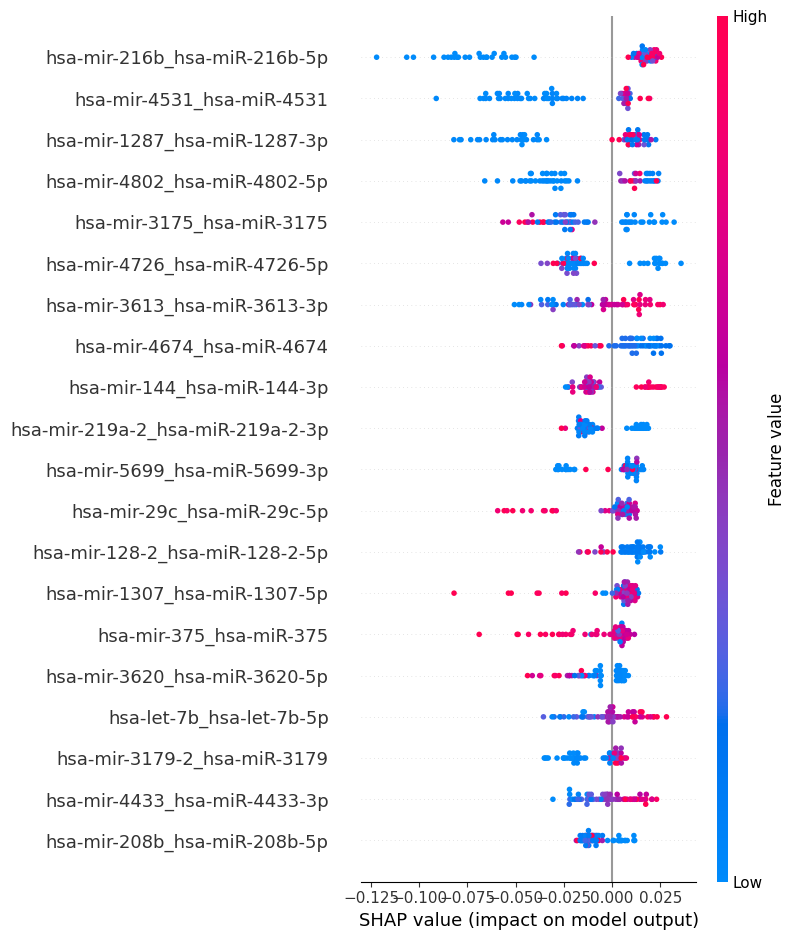

In [19]:
explainer = shap.TreeExplainer(final_rf)
shap_values = explainer.shap_values(X_test_selected)

shap.summary_plot(
    shap_values[:, :, 1], X_test_selected, feature_names=winning_micrornas
)


In [55]:
winning_features = X_train.columns[boruta_selector.support_]

df_features = pd.DataFrame({'Ranked_Biomarker_miRNA': winning_features})
df_features.to_csv('boruta_winning_features.csv', index=False)

print(f"Successfully saved {len(winning_features)} biomarkers to 'boruta_winning_features.csv'!")

🎉 Successfully saved 56 biomarkers to 'boruta_winning_features.csv'!
